In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

In [3]:
df = pd.read_csv(data)

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [4]:
df.shape

(10000, 11)

In [5]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [6]:
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

new_df = df[columns]

In [7]:
new_df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [8]:
new_df.shape

(10000, 5)

### Exploratory Data Analysis

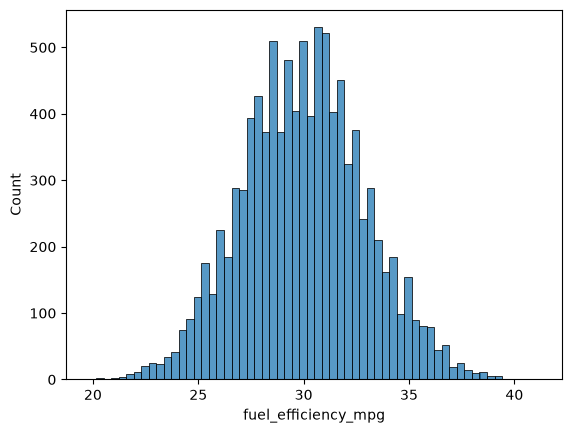

In [9]:
sns.histplot(new_df['fuel_efficiency_mpg']);

In [10]:
new_df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [11]:
# median of horsepower
print(new_df['horsepower'].median())

254.0


### Split the dataset

In [12]:
n = len(new_df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = new_df.iloc[idx[:n_train]]
df_val = new_df.iloc[idx[n_train:n_train + n_val]]
df_test = new_df.iloc[idx[n_train+n_val:]]


In [13]:
n, (n_val + n_test + n_train)

(10000, 10000)

In [14]:
df_train.shape, df_val.shape, df_test.shape

((6000, 5), (2000, 5), (2000, 5))

In [15]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [16]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
7895,2280,242.0,4590,2018,29.8
9590,2300,NaN,4240,1984,25.1
7288,2240,255.0,4190,1989,27.7
278,2430,254.0,4280,2020,31.6


In [17]:
df_train = df_train.reset_index(drop=True)
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
5995,2280,242.0,4590,2018,29.8
5996,2300,NaN,4240,1984,25.1
5997,2240,255.0,4190,1989,27.7
5998,2430,254.0,4280,2020,31.6


In [18]:
df_test = df_test.reset_index(drop=True)
df_test

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2370,268.0,4410,1981,27.8
1,2240,256.0,4220,2020,37.3
2,2090,217.0,3910,2023,33.1
3,2280,251.0,4420,2021,31.3
4,2450,256.0,4420,1979,26.4
...,...,...,...,...,...
1995,2100,257.0,4130,1988,30.7
1996,2160,231.0,4180,2000,25.5
1997,2430,246.0,4660,2013,30.1
1998,2450,307.0,4500,2014,30.5


In [19]:
df_val = df_val.reset_index(drop=True)
df_val

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2240,265.0,3990,2004,30.4
1,2390,259.0,4770,2019,32.8
2,2360,265.0,4320,2018,27.8
3,2430,279.0,4430,2008,28.6
4,2220,249.0,4030,1999,31.1
...,...,...,...,...,...
1995,1980,229.0,4140,2020,30.3
1996,2590,263.0,4630,1989,28.7
1997,2390,264.0,4550,2017,30.6
1998,2330,244.0,4440,2014,31.0


In [20]:
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

In [21]:
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [22]:
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [23]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001
...,...,...,...,...
5995,2280,242.0,4590,2018
5996,2300,NaN,4240,1984
5997,2240,255.0,4190,1989
5998,2430,254.0,4280,2020


In [24]:
len(y_train)

6000

In [25]:
X_train = df_train.values

In [26]:
X_train

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [27]:
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [28]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [29]:
w0, w = train_linear_regression(X_train, y_train)

### Training on the mean of the missing variables

In [30]:
df_train.isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

In [31]:
n = len(new_df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = new_df.iloc[idx[:n_train]]
df_val = new_df.iloc[idx[n_train:n_train + n_val]]
df_test = new_df.iloc[idx[n_train+n_val:]]


In [32]:
df_train.isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [33]:
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [34]:
mean = df_train['horsepower'].mean()
mean

np.float64(254.46338337605272)

In [35]:
df_train['horsepower'] = df_train['horsepower'].fillna(mean)

df_train.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [36]:
X_train = df_train.values
X_train

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [37]:
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [38]:
def train_linear_regression(X,y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [39]:
w0, w = train_linear_regression(X_train, y_train)

In [40]:
w0

np.float64(-153.29645639182718)

In [41]:
w

array([-0.00102386, -0.00648622, -0.00388828,  0.10197897])

In [42]:
y_pred = w0 + X_train.dot(w)
y_pred

array([33.9590606 , 29.31436861, 32.76131994, ..., 29.30040609,
       31.92376266, 29.67268373], shape=(6000,))

### RMSE

In [43]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    rmse = np.sqrt(mse)
    return rmse

## Validating the model

In [44]:
n = len(new_df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = new_df.iloc[idx[:n_train]]
df_val = new_df.iloc[idx[n_train:n_train + n_val]]
df_test = new_df.iloc[idx[n_train+n_val:]]


In [45]:
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [46]:

X_train = df_train.fillna(0).values

w0, w = train_linear_regression(X_train, y_train)

y_pred_zero = w0 + X_train.dot(w)

In [47]:
def prepare_X(df):
    df_num = df_train
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [48]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_train = prepare_X(df_train)
y_pred_zero = w0 + X_train.dot(w)

score = rmse(y_train, y_pred_zero)
print(round(score, 3))

2.2


In [49]:
# mean

n = len(new_df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = new_df.iloc[idx[:n_train]]
df_val = new_df.iloc[idx[n_train:n_train + n_val]]
df_test = new_df.iloc[idx[n_train+n_val:]]


In [50]:
del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [51]:

X_train = df_train.fillna(df_train.mean()).values

w0, w = train_linear_regression(X_train, y_train)

y_pred_mean = w0 + X_train.dot(w)

In [52]:
def prepare_X(df):
    df_num = df_val
    df_num = df_num.fillna(df_val.mean())
    X = df_num.values
    return X

In [53]:
X_val = df_val.values

In [54]:
X_val = prepare_X(df_val)
y_pred_mean = w0 + X_val.dot(w)

score = rmse(y_val, y_pred_mean)
print(round(score, 3))

2.202


### Regularization

In [55]:
columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year'
]
def prepare_X(df):
    df = df.copy()
    
    df_num = df[columns]
    df_num = df_num.fillna(0)
    X = df_num.values
    
    return X

In [56]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

score  = rmse(y_val, y_pred)
print(round(score, 3))

2.205


In [57]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [58]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

score = rmse(y_val, y_pred)
print(score.round(3))

2.206


### Tuning the model

In [59]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    print(r, score)

0 2.205293194751098
0.01 2.205827616672006
0.1 2.2241432777850636
1 2.349228888392786
5 2.409380166599679
10 2.4194698654732387
100 2.4292021380162367


In [60]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

score = rmse(y_val, y_pred)
print(score.round(3))

2.205


### Testing the seeds

In [61]:
scores = []

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

for seed in range(10):
    np.random.seed(seed)

    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    df_test = df.iloc[idx[n_train + n_val:]].copy()

    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    scores.append(score)

print(scores)
print(np.std(scores))
print(round(np.std(scores), 3))

[np.float64(2.2392041430461465), np.float64(2.2021128210838907), np.float64(2.163419778753095), np.float64(2.2043588768539144), np.float64(2.2018800943312926), np.float64(2.2457851509084974), np.float64(2.269721207952404), np.float64(2.190794599933433), np.float64(2.2166112016864443), np.float64(2.207036592817851)]
0.028781274078187116
0.029


In [124]:
n = len(new_df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = new_df.iloc[idx[:n_train]]
df_val = new_df.iloc[idx[n_train:n_train + n_val]]
df_test = new_df.iloc[idx[n_train+n_val:]]


In [125]:
def prepare_X(df):
    df_num = df
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [126]:
df_full_train = pd.concat([df_train, df_val])

df_full_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
3644,2320,246.0,4100,2014,32.5
9184,2230,252.0,4250,1998,33.2
520,2700,276.0,4490,2008,32.4
5685,2220,269.0,4060,2004,29.9
2401,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
8981,2690,324.0,4510,2023,35.7
3978,1920,190.0,4000,1998,30.8
6198,1800,225.0,3980,1994,29.1
1102,1970,232.0,3560,2009,32.2


In [127]:
df_full_train = df_full_train.reset_index(drop=True)

df_full_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2320,246.0,4100,2014,32.5
1,2230,252.0,4250,1998,33.2
2,2700,276.0,4490,2008,32.4
3,2220,269.0,4060,2004,29.9
4,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
7995,2690,324.0,4510,2023,35.7
7996,1920,190.0,4000,1998,30.8
7997,1800,225.0,3980,1994,29.1
7998,1970,232.0,3560,2009,32.2


In [128]:
y_full_train = df_full_train['fuel_efficiency_mpg']

In [129]:
del df_full_train['fuel_efficiency_mpg']

In [130]:
X_train_full = prepare_X(df_full_train)

X_train_full

array([[2320.,  246., 4100., 2014.],
       [2230.,  252., 4250., 1998.],
       [2700.,  276., 4490., 2008.],
       ...,
       [1800.,  225., 3980., 1994.],
       [1970.,  232., 3560., 2009.],
       [2180.,  254., 3970., 2018.]], shape=(8000, 4))

In [131]:
print(X_train_full.shape)
print(y_train_full.shape)

(8000, 4)
(8000,)


In [132]:
w0, w = train_linear_regression_reg(X_train_full, y_train_full, r=0.001)

In [133]:
w0

np.float64(-152.37535772493302)

In [134]:
w

array([-0.00135534, -0.00042645, -0.00401765,  0.10140402])

### Preparing the test data

In [135]:
y_test = df_test['fuel_efficiency_mpg'].values

df_test = df_test.drop(columns=['fuel_efficiency_mpg'])

X_test = prepare_X(df_test)

In [136]:
y_test

array([29. , 35.7, 26.2, ..., 31. , 27.2, 34.3], shape=(2000,))

In [139]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred).round(3)
print(score)

2.236
